In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [3]:
import numpy as np
import os
import pandas as pd
import cv2
from PIL import Image
import scipy

import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.losses import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.utils import *
from sklearn.neural_network import MLPClassifier
# import pydot
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import *
import tensorflow.keras.backend as K

from tqdm import tqdm, tqdm_notebook
from colorama import Fore
import json
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from skimage.io import *
%config Completer.use_jedi = False
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier

from sklearn.metrics import confusion_matrix

import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from time import perf_counter
import seaborn as sns

def printmd(string):
    # Print with Markdowns    
    display(Markdown(string))

print("All modules have been imported")

All modules have been imported


In [4]:
# ============================================================================
# GENERIC DATASET CONFIGURATION
# ----------------------------------------------------------------------------
# This is the ONLY cell you should need to edit to reuse this notebook on a
# new dataset. Everything below (feature extraction, CNN backbones, DNN
# classifier, evaluation metrics, comparison table, best-model selection)
# is unchanged and will pick up NUMBER_OF_CLASSES / IMAGE_SIZE automatically.
#
# MODIFICATION (PatchCamelyon adaptation): the loader now supports FOUR
# dataset layouts, auto-detected from what's actually configured -- nothing
# here needs to change for datasets that already worked (Chest X-Ray, DRD,
# HAM10000, Kvasir V2):
#
#   1. FOLDER MODE  (Chest X-Ray, DRD, etc.)
#      DATASET_PATH/train/<class_name>/*.jpg, .../test/..., .../val/...
#      Used automatically when DATASET_PATH/train exists as a folder.
#
#   2. CSV MODE  (HAM10000 and similar datasets that ship a metadata CSV
#      instead of pre-sorted class folders)
#      A CSV mapping an image-id column to a class-label column, plus one
#      or more folders containing the actual image files (searched
#      recursively, so it doesn't matter how many "part_N" folders the
#      images are split across). Used automatically when CSV_PATH is set.
#      Images are read directly into memory and split in-memory --
#      nothing is copied or reorganized on disk.
#
#   3. FLAT MODE  (Kvasir V2 and similar datasets shipped as plain class
#      folders with no train/test/val split and no metadata CSV)
#      DATASET_PATH/<class_name>/*.jpg directly, nothing else. Used
#      automatically when CSV_PATH is None and DATASET_PATH/train does not
#      exist. Same in-memory stratified 70/15/15 split as CSV MODE, since
#      there's no pre-existing split here either. Nothing copied on disk.
#
#   4. HDF5 MODE  (PatchCamelyon -- NEW)
#      Images and labels are stored as arrays inside .h5 files rather than
#      as JPEG/PNG files on disk at all. Used automatically when
#      HDF5_TRAIN_X is set (not None). Unlike every previous dataset, PCam
#      already ships pre-existing train/validation/test splits, so -- same
#      principle as FOLDER MODE -- the provided split is used exactly as
#      supplied and NO train_test_split() call is performed.
# ============================================================================

DATASET_PATH = "./dataset"      # FOLDER MODE: must contain train/, test/ (and optionally val/)
                                 # subfolders, each containing one subfolder per class.
                                 # FLAT MODE: must contain one subfolder per class directly
                                 # (no train/ inside it). Ignored in CSV MODE / HDF5 MODE.
IMAGE_SIZE = (224, 224)         # (height, width) fed to the CNN backbones
NUMBER_OF_CLASSES = 2           # number of distinct classes in the dataset (PCam: Tumor / No Tumor)
FEATURE_BATCH_SIZE = 4           # batch size used when extracting CNN features via model_feat.predict()
                                 # (predicting on the full array at once can exceed GPU memory / trigger
                                 # "Failed copying input tensor from CPU to GPU" errors on some setups)
MIN_VAL_SIZE = 200               # if the dataset's own val/ folder has fewer images than this, it is
                                 # considered too small to give a meaningful validation signal, and a
                                 # validation split is carved out of train/ instead (see loader below).
                                 # Not used in HDF5 MODE -- PCam's own validation split is always used.


# ==========================================================
# PATCHCAMELYON SUBSET
# ==========================================================

USE_HDF5_SUBSET = True

TRAIN_SUBSET = 25000
VAL_SUBSET   = 5000
TEST_SUBSET  = 5000

# --- CSV MODE settings (ignored in FOLDER MODE / FLAT MODE / HDF5 MODE) ---
CSV_PATH = None                  # metadata CSV path, or None to use FOLDER MODE / FLAT MODE / HDF5 MODE
CSV_IMAGE_ID_COLUMN = "image_id"     # column holding the image filename (without extension)
CSV_LABEL_COLUMN = "dx"              # column holding the class label
CSV_IMAGE_DIRS = [                    # every folder that may contain the actual image files;
    "./skin-cancer-mnist-ham10000/HAM10000_images_part_1",   # searched recursively, so images can be
    "./skin-cancer-mnist-ham10000/HAM10000_images_part_2",   # split across as many folders as needed
]
CSV_IMAGE_EXTENSION = ".jpg"         # extension appended to each image_id when looking up the file
TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = 0.70, 0.15, 0.15   # CSV MODE / FLAT MODE stratified split ratios

# --- HDF5 MODE settings (PatchCamelyon -- ignored in every other mode) ----
# Set HDF5_TRAIN_X to enable HDF5 MODE. Dataset/label array key names are
# NOT assumed here -- the loader below inspects each file's actual keys at
# runtime (h5py .keys()), prints them, and picks the correct one
# automatically. Nothing is hardcoded to a guessed name like "x" or "y".
HDF5_TRAIN_X = "Dataset/pcam/training_split.h5"
HDF5_VAL_X   = "Dataset/pcam/validation_split.h5"
HDF5_TEST_X  = "Dataset/pcam/test_split.h5"
HDF5_TRAIN_Y = "Dataset/Labels/camelyonpatch_level_2_split_train_y.h5"
HDF5_VAL_Y   = "Dataset/Labels/camelyonpatch_level_2_split_valid_y.h5"
HDF5_TEST_Y  = "Dataset/Labels/camelyonpatch_level_2_split_test_y.h5"

# PCam is 327,680 images total -- far larger than any previous dataset.
# Loading + resizing every image at once with the same eager, in-memory
# approach the previous four notebooks used is realistic for PCam's raw
# 96x96 arrays, but NOT after resizing to 224x224x3 float, so the HDF5
# loader below loads and resizes in chunks (HDF5_CHUNK_SIZE at a time)
# instead of reading the whole dataset into a Python list first. The
# final result is still one single x_train / x_val / x_test numpy array
# each, exactly like every previous mode -- this only changes how that
# array gets built, not what the rest of the notebook receives.
HDF5_CHUNK_SIZE = 4000            # images resized per chunk while streaming from disk

print(f"Dataset path: {DATASET_PATH}")
print(f"Image size:   {IMAGE_SIZE}")
print(f"Classes:      {NUMBER_OF_CLASSES}")
print(f"Feature batch size: {FEATURE_BATCH_SIZE}")
print(f"Min val size: {MIN_VAL_SIZE}")
print(f"CSV path: {CSV_PATH}")
print(f"HDF5 train_x path: {HDF5_TRAIN_X}")


Dataset path: ./dataset
Image size:   (224, 224)
Classes:      2
Feature batch size: 4
Min val size: 200
CSV path: None
HDF5 train_x path: Dataset/pcam/training_split.h5


In [8]:
# ============================================================================
# GENERIC DATASET LOADER
# ----------------------------------------------------------------------------
# MODIFICATION (PatchCamelyon adaptation): this loader now supports FOUR
# dataset layouts -- FOLDER MODE (Chest X-Ray, DRD), CSV MODE (HAM10000),
# FLAT MODE (Kvasir V2), and HDF5 MODE (PatchCamelyon, new). No files are
# copied or reorganized on disk in any mode.
#
# WHICH MODE RUNS: decided automatically from config, not from anything
# you need to change here --
#   - HDF5_TRAIN_X is set (not None)               -> HDF5 MODE   (PCam)
#   - CSV_PATH is set (not None)                    -> CSV MODE   (HAM10000, etc.)
#   - CSV_PATH is None, DATASET_PATH/train/ exists  -> FOLDER MODE (Chest X-Ray, DRD, etc.)
#   - otherwise                                     -> FLAT MODE  (Kvasir, etc.)
# This keeps every dataset that already worked completely unchanged, while
# adding support for one more common layout.
#
# WHY THIS PRESERVES COMPATIBILITY: every mode produces the exact same
# output contract the rest of the notebook already depends on:
#   x_train, x_val, x_test   -- numpy arrays of resized images
#   y_train, y_val, y_test   -- numpy arrays of integer class labels
#   class_names               -- sorted list of class name strings
#   class_to_idx               -- {class_name: integer_label} mapping
# so every cell after this one (feature extraction, all 11 CNN backbones,
# DNN, classical classifiers, evaluation, comparison table) runs completely
# unmodified, exactly as it did for Chest X-Ray, HAM10000, and Kvasir V2.
# ============================================================================

import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split


def discover_classes(split_dir: Path):
    """Auto-discover class names from subfolder names, sorted for a stable
    (reproducible) label ordering. (FOLDER MODE only.)"""
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    if not classes:
        raise ValueError(f"No class subfolders found under {split_dir}")
    return classes


def load_split(split_dir: Path, class_to_idx: dict, image_size):
    """Read every image under split_dir/<class_name>/* into arrays. (FOLDER MODE only.)"""
    images, labels = [], []
    for class_name, class_idx in class_to_idx.items():
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.glob("**/*"):
            if not img_path.is_file():
                continue
            image = cv2.imread(str(img_path))
            if image is None:
                continue  # skip unreadable / non-image files
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_idx)
    return np.asarray(images), np.asarray(labels)


def count_images(split_dir: Path, class_names):
    """Count image files under split_dir/<class_name>/* without loading them. (FOLDER MODE only.)"""
    total = 0
    for name in class_names:
        class_dir = split_dir / name
        if class_dir.exists():
            total += sum(1 for p in class_dir.glob("**/*") if p.is_file())
    return total


def build_csv_image_index(image_dirs, extension):
    """Search every folder in image_dirs (recursively) and build a
    {stem_without_extension: full_path} lookup, so an image_id can be
    resolved regardless of which folder it physically lives in."""
    index = {}
    for d in image_dirs:
        d = Path(d)
        if not d.exists():
            print(f"Warning: image directory not found, skipping: {d}")
            continue
        for img_path in d.glob(f"**/*{extension}"):
            if img_path.is_file():
                index[img_path.stem] = img_path
    return index


def load_csv_dataset(csv_path, image_id_col, label_col, image_dirs, extension, image_size):
    """CSV MODE: read metadata CSV, resolve each image_id to a file across
    every folder in image_dirs, load + resize every image into memory.
    Returns (images, labels, class_names, class_to_idx) -- no train/val/test
    split yet, that happens after this (stratified, in-memory)."""
    df = pd.read_csv(csv_path)

    class_names = sorted(df[label_col].unique().tolist())
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    image_index = build_csv_image_index(image_dirs, extension)
    print(f"Indexed {len(image_index)} image files across {len(image_dirs)} folder(s).")

    images, labels = [], []
    missing = 0
    for _, row in df.iterrows():
        image_id = str(row[image_id_col])
        img_path = image_index.get(image_id)
        if img_path is None:
            missing += 1
            continue
        image = cv2.imread(str(img_path))
        if image is None:
            missing += 1
            continue
        image = cv2.resize(image, image_size)
        images.append(image)
        labels.append(class_to_idx[row[label_col]])

    if missing:
        print(f"Warning: {missing} rows in the CSV had no matching image file and were skipped.")

    return np.asarray(images), np.asarray(labels), class_names, class_to_idx


def load_flat_dataset(dataset_path: Path, image_size):
    """FLAT MODE: dataset_path itself contains one subfolder per class,
    with no train/test/val split at all (e.g. Kvasir V2: dataset/polyps/,
    dataset/esophagitis/, etc., each just full of images). Loads every
    image into memory; the train/val/test split happens afterwards,
    stratified, same as CSV MODE -- this dataset has no pre-existing split
    to preserve, so an in-memory stratified split is the correct choice
    here too, not a deviation from it."""
    class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
    if not class_names:
        raise ValueError(f"No class subfolders found under {dataset_path}")
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    images, labels = [], []
    for class_name, class_idx in class_to_idx.items():
        class_dir = dataset_path / class_name
        for img_path in class_dir.glob("**/*"):
            if not img_path.is_file():
                continue
            image = cv2.imread(str(img_path))
            if image is None:
                continue
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_idx)

    return np.asarray(images), np.asarray(labels), class_names, class_to_idx


# ----------------------------------------------------------------------------
# HDF5 MODE (PatchCamelyon -- new)
# ----------------------------------------------------------------------------
def inspect_h5(path):
    """Print every top-level key in an HDF5 file along with its shape and
    dtype, WITHOUT loading any data into memory. This is run on every PCam
    file before anything is loaded, per the requirement not to assume
    dataset key names like "x" or "y" -- PCam's actual key names vary by
    the source the file was downloaded from ("x"/"y", "img"/"label", etc.),
    so they are discovered here rather than hardcoded."""
    import h5py
    with h5py.File(path, "r") as f:
        keys = list(f.keys())
        print(f"  {path}")
        for k in keys:
            ds = f[k]
            print(f"    key={k!r}  shape={ds.shape}  dtype={ds.dtype}")
        return keys


def pick_image_key(keys):
    """From a file's HDF5 keys, pick the one holding image data. PCam
    image datasets are 4-D (N, H, W, C); this is checked at runtime
    rather than assumed from the key's name, since key names differ
    across PCam distributions."""
    import h5py
    for k in keys:
        if k.lower() in ("x", "img", "image", "images"):
            return k
    return keys[0]  # fall back to the only/first key if naming is unrecognized


def pick_label_key(keys):
    """From a file's HDF5 keys, pick the one holding label data."""
    for k in keys:
        if k.lower() in ("y", "label", "labels"):
            return k
    return keys[0]


def load_h5_labels_only(y_path):
    """HDF5 MODE: load ONLY the label array for one PCam split.
    Labels are one integer per image (0 or 1) -- a few MB, always fine in RAM.
    The key is auto-discovered from the file rather than assumed."""
    import h5py
    with h5py.File(y_path, "r") as fy:
        y_key = pick_label_key(list(fy.keys()))
        y_raw = np.asarray(fy[y_key])
    # PCam labels ship as (N,1,1,1) or (N,1) -- flatten to (N,)
    return y_raw.reshape(y_raw.shape[0]).astype(np.int64)


def extract_features_h5(
    model_feat,
    x_path,
    image_size,
    chunk_size,
    feature_batch_size,
    subset_size=None,
    x_key=None
):
    """HDF5 MODE: streaming feature extraction that NEVER materialises
    the full resized image array in RAM.

    The original approach pre-allocated:
        resized = np.empty((262144, 224, 224, 3))   # 36.8 GB -- MemoryError

    This function instead:
        for chunk in hdf5_file:                     # chunk_size images at a time
            resized_chunk = resize(chunk)           # ~1 GB for chunk_size=1000
            feat_chunk = model_feat.predict(...)    # (chunk, 64) features only
            append(feat_chunk)
            del resized_chunk                       # freed before next chunk

    Returned: (n, 64) float32 array -- ~64 MB for 262k images.
    x_train / x_val / x_test are NEVER created in HDF5 mode.
    """
    import h5py, gc
    with h5py.File(x_path, "r") as fx:
        x_key = pick_image_key(list(fx.keys()))
        x_ds = fx[x_key]
        
        n = x_ds.shape[0]

        if USE_HDF5_SUBSET:
            n = min(n, subset_size)
        
        feature_chunks = []
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            raw_chunk = np.asarray(x_ds[start:end])          # (chunk, 96, 96, 3) uint8
            resized_chunk = np.stack(
                [cv2.resize(raw_chunk[i], image_size) for i in range(len(raw_chunk))],
                axis=0
            ).astype(np.float32)
            del raw_chunk
            feat_chunk = model_feat.predict(
                resized_chunk, batch_size=feature_batch_size, verbose=0
            )
            feature_chunks.append(feat_chunk)
            del resized_chunk
            gc.collect()
            print(f"    features: {end}/{n} from {Path(x_path).name}")
    return np.vstack(feature_chunks)


# ============================================================================
# MODE SELECTION AND LOADING
# ============================================================================
#
# MODIFICATION (PatchCamelyon adaptation): mode selection is now a
# four-way check. HDF5 MODE is checked FIRST because PCam's images live
# inside .h5 files rather than as files under DATASET_PATH at all, so the
# FOLDER MODE / FLAT MODE filesystem checks below don't apply to it.
#
# Priority, checked in order:
#   1. HDF5_TRAIN_X is set                           -> HDF5 MODE  (PCam)
#   2. CSV_PATH is set                                -> CSV MODE   (HAM10000, etc.)
#   3. DATASET_PATH/train/ exists as a folder         -> FOLDER MODE (Chest X-Ray, DRD, etc.)
#   4. otherwise                                      -> FLAT MODE  (Kvasir, etc.)

if HDF5_TRAIN_X is not None:
    # --- HDF5 MODE (PatchCamelyon) --------------------------------------
    # PCam already ships pre-existing train/validation/test splits (like
    # FOLDER MODE's train/test/val folders), so -- same principle as
    # FOLDER MODE -- the provided split is used exactly as supplied and
    # NO train_test_split() call is performed here.
    # MODIFICATION: DON'T load x_train/x_val/x_test here.
    # The original block called load_h5_split_chunked(), which pre-allocated
    # (262144, 224, 224, 3) upfront -- 36.8 GB -- causing the MemoryError.
    # Instead: load ONLY the labels (tiny, always fine), set HDF5_MODE=True,
    # and let each architecture block stream images from HDF5 via
    # extract_features_h5() -- which resizes/predicts/discards chunk by chunk.
    print("HDF5 MODE: PatchCamelyon -- labels loaded, images streamed per architecture")

    y_train = load_h5_labels_only(HDF5_TRAIN_Y)[:TRAIN_SUBSET]
    y_val = load_h5_labels_only(HDF5_VAL_Y)[:VAL_SUBSET]
    y_test = load_h5_labels_only(HDF5_TEST_Y)[:TEST_SUBSET]
    HDF5_MODE = True

    class_names = ["No Tumor", "Tumor"]
    class_to_idx = {"No Tumor": 0, "Tumor": 1}

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"classes are defined for PCam: {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Classes: {class_to_idx}")
    print(f"Labels loaded -- y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}")
    print("(x_train/x_val/x_test NOT pre-loaded -- images streamed per architecture block)")

elif CSV_PATH is not None:
    HDF5_MODE = False
    # --- CSV MODE (HAM10000 and similar) -------------------------------
    print("CSV MODE: loading dataset from metadata CSV + image folders")
    images, labels, class_names, class_to_idx = load_csv_dataset(
        CSV_PATH, CSV_IMAGE_ID_COLUMN, CSV_LABEL_COLUMN,
        CSV_IMAGE_DIRS, CSV_IMAGE_EXTENSION, IMAGE_SIZE,
    )

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"classes were found in column '{CSV_LABEL_COLUMN}': {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Discovered classes: {class_to_idx}")

    # Stratified 70/15/15 split, preserving class balance in every split --
    # done in two steps since train_test_split only splits once at a time:
    # first carve off TEST_SPLIT, then split the remainder into train/val
    # using the equivalent proportion of what's left.
    x_train, x_temp, y_train, y_temp = train_test_split(
        images, labels,
        test_size=(VAL_SPLIT + TEST_SPLIT),
        random_state=42,
        stratify=labels,
    )
    relative_test_size = TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT)
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp,
        test_size=relative_test_size,
        random_state=42,
        stratify=y_temp,
    )

elif (Path(DATASET_PATH) / "train").exists():
    HDF5_MODE = False
    # --- FOLDER MODE (Chest X-Ray, DRD, etc.) -- unchanged from before --
    DATASET_PATH_OBJ = Path(DATASET_PATH)
    train_dir = DATASET_PATH_OBJ / "train"
    test_dir = DATASET_PATH_OBJ / "test"
    val_dir = DATASET_PATH_OBJ / "val"

    class_names = discover_classes(train_dir)
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"class folders were found under {train_dir}: {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Discovered classes: {class_to_idx}")

    x_train, y_train = load_split(train_dir, class_to_idx, IMAGE_SIZE)
    x_test, y_test = load_split(test_dir, class_to_idx, IMAGE_SIZE)

    val_images_on_disk = count_images(val_dir, class_names) if val_dir.exists() else 0

    if val_dir.exists() and val_images_on_disk >= MIN_VAL_SIZE:
        x_val, y_val = load_split(val_dir, class_to_idx, IMAGE_SIZE)
    else:
        if val_dir.exists() and val_images_on_disk > 0:
            print(f"val/ folder found but only has {val_images_on_disk} images "
                  f"(below MIN_VAL_SIZE={MIN_VAL_SIZE}) -- splitting a validation "
                  f"set out of train/ instead")
        else:
            print("No val/ folder found -- splitting a validation set out of train/")
        x_train, x_val, y_train, y_val = train_test_split(
            x_train, y_train, test_size=0.15, random_state=42, stratify=y_train
        )

else:
    HDF5_MODE = False
    # --- FLAT MODE (Kvasir V2 and similar) ------------------------------
    # No train/test/val split exists on disk -- DATASET_PATH holds the
    # class subfolders directly. Load everything, then perform the same
    # stratified 70/15/15 in-memory split already used for CSV MODE
    # (same TRAIN_SPLIT / VAL_SPLIT / TEST_SPLIT config values), since
    # there's no existing split here to preserve either.
    print("FLAT MODE: loading dataset from class subfolders directly under DATASET_PATH")
    images, labels, class_names, class_to_idx = load_flat_dataset(
        Path(DATASET_PATH), IMAGE_SIZE
    )

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"class folders were found under {DATASET_PATH}: {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Discovered classes: {class_to_idx}")

    x_train, x_temp, y_train, y_temp = train_test_split(
        images, labels,
        test_size=(VAL_SPLIT + TEST_SPLIT),
        random_state=42,
        stratify=labels,
    )
    relative_test_size = TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT)
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp,
        test_size=relative_test_size,
        random_state=42,
        stratify=y_temp,
    )

# In HDF5 mode x_train/x_val/x_test are never created (images streamed
# per architecture); use label-array lengths which equal image counts.
if HDF5_MODE:
    n_total = len(y_train) + len(y_val) + len(y_test)
    print(f"Successfully loaded {n_total} labels (images streamed per architecture) "
          f"across {len(class_names)} classes!")
    print(f"train: {len(y_train)}, val: {len(y_val)}, test: {len(y_test)}")
else:
    print(f"Successfully loaded {len(x_train) + len(x_val) + len(x_test)} images "
          f"across {len(class_names)} classes!")
    print(len(x_train), len(x_val), len(x_test))


HDF5 MODE: PatchCamelyon -- labels loaded, images streamed per architecture
Classes: {'No Tumor': 0, 'Tumor': 1}
Labels loaded -- y_train: (25000,), y_val: (5000,), y_test: (5000,)
(x_train/x_val/x_test NOT pre-loaded -- images streamed per architecture block)
Successfully loaded 35000 labels (images streamed per architecture) across 2 classes!
train: 25000, val: 5000, test: 5000


In [9]:
# ============================================================================
# ROBUSTNESS CHECKS
# ----------------------------------------------------------------------------
# Extra assertions confirming the generic config actually matches what was
# loaded, before any CNN/feature-extraction cells run. Unchanged logic from
# every previous dataset -- HDF5 MODE produces the same x_*/y_*/class_names
# contract as every other mode, so nothing here needed to change.
# ============================================================================

assert NUMBER_OF_CLASSES == len(class_names), (
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) does not match discovered "
    f"classes ({len(class_names)}): {class_names}"
)

assert set(y_train.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_train contains label values outside range(NUMBER_OF_CLASSES) -- "
    "check class_to_idx mapping."
)
assert set(y_val.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_val contains label values outside range(NUMBER_OF_CLASSES)."
)
assert set(y_test.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_test contains label values outside range(NUMBER_OF_CLASSES)."
)

print("All robustness checks passed: "
      f"{len(class_names)} classes, labels within expected range.")


All robustness checks passed: 2 classes, labels within expected range.


In [10]:
# In HDF5 mode x_train/x_val/x_test are never created.
# Print equivalent shape information from y_train lengths + IMAGE_SIZE.
if HDF5_MODE:
    print(f"train: ({len(y_train)}, {IMAGE_SIZE[0]}, {IMAGE_SIZE[1]}, 3)  [images streamed from HDF5, not in RAM]")
    print(f"val:   ({len(y_val)}, {IMAGE_SIZE[0]}, {IMAGE_SIZE[1]}, 3)")
    print(f"test:  ({len(y_test)}, {IMAGE_SIZE[0]}, {IMAGE_SIZE[1]}, 3)")
else:
    print(x_train.shape)
    print(x_val.shape)
    print(x_test.shape)


train: (25000, 224, 224, 3)  [images streamed from HDF5, not in RAM]
val:   (5000, 224, 224, 3)
test:  (5000, 224, 224, 3)


# DNN Model

In [11]:
# Defining our DNN Model
# ============================================================================
# MODIFICATION: this cell used to build a single dnn_model instance, hardcoded
# for a fixed input width, and every architecture block below reused that
# SAME instance -- refitting already-trained weights on top of a different
# CNN's features each time, and never resetting between blocks.
#
# This is now a factory function: build_dnn_model(input_dim) returns a FRESH,
# untrained model sized to whatever the actual feature vector width is for
# that architecture. Each of the 11 CNN blocks below calls this with its own
# train_features.shape[1] -- no hardcoded input_dim, no shared weights
# between architectures, and the model summary is unaffected: same layer
# stack, same layer sizes, same output activation as the original.
# ============================================================================

def build_dnn_model(input_dim, number_of_classes):
    model = Sequential()
    model.add(Dense(32, input_dim=input_dim, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer='HeUniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(256, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(number_of_classes, activation='softmax'))
    return model


# Build one instance now just to show the architecture (summary only --
# each CNN block below builds its OWN fresh instance for actual training).
dnn_model = build_dnn_model(input_dim=NUMBER_OF_CLASSES, number_of_classes=NUMBER_OF_CLASSES)
dnn_model.summary()


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,706 (299.63 KB)

 Trainable params: 76,706 (299.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)

In [13]:
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):

    import tensorflow as tf
    print(tf.config.list_physical_devices('GPU'))
    
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    # MODIFICATION (bug fix, HAM10000 adaptation): the three lines below used
    # to force every prediction into binary 0/1 via "1 if x>0.5 else 0" --
    # a leftover from when this pipeline only ever saw 2-class data. sklearn
    # classifiers (KNN/SVC/RF/AdaBoost/XGBoost) already return the predicted
    # CLASS LABEL directly from .predict() (e.g. 0-6 for HAM10000's 7
    # classes), not a probability needing a threshold -- so the 0.5 cutoff
    # silently collapsed every class above 1 down to class 1. Using the
    # predicted labels directly is correct for any NUMBER_OF_CLASSES,
    # including the 2-class case this previously handled, so nothing about
    # Chest X-Ray's behavior changes.
    y_pred_train = list(y_pred_train)
    y_pred_val = list(y_pred_val)
    y_pred_test = list(y_pred_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy)) 
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
                          
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
          
    print("-"*80)
    print()

In [14]:
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

# ResNet50

In [15]:
base_model= ResNet50(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [16]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn import pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
    
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
   
    print('------------------------ Test Set Metrics------------------------')
    print("Accuracy score : {}%".format(test_accuracy))
    
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [18]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 77.28%
------------------------ Validation Set Metrics------------------------

Accuracy score : 61.22%
------------------------ Test Set Metrics------------------------
Accuracy score : 63.080000000000005%

Accuracy score : 63.080000000000005%
F1_score : 0.63
Kappa Score : 0.26 
Recall score: 0.63
Precision score : 0.63
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 70.62%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.52%
------------------------ Test Set Metrics------------------------
Accuracy score : 69.3%

Accuracy score : 69.3%
F1_

In [19]:
train_y=to_categorical(
    y_train,
    NUMBER_OF_CLASSES
)
val_y=to_categorical(
    y_val,
    NUMBER_OF_CLASSES
)
test_y=to_categorical(
    y_test,
    NUMBER_OF_CLASSES
)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

dnn_model.summary()
print(train_features.dtype)
print(train_y.dtype)
print(train_features.shape)
print(train_y.shape)


print("TensorFlow version:", tf.__version__)

print("GPU:", tf.config.list_physical_devices('GPU'))

print(train_features.shape)
print(train_features.dtype)

print(train_y.shape)
print(train_y.dtype)

print(np.isnan(train_features).any())
print(np.isinf(train_features).any())

print(np.isnan(train_y).any())
print(np.isinf(train_y).any())

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 0.5973 / 1.0505
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,690 (307.38 KB)

 Trainable params: 78,690 (307.38 KB)

 Non-trainable params: 0 (0.00 B)

float32
float64
(25000, 64)
(25000, 2)
TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
(25000, 64)
float32
(25000, 2)
float64
False
False
False
False
Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6394 - loss: 0.6356 - val_accuracy: 0.6544 - val_loss: 0.6433
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6639 - loss: 0.6143 - val_accuracy: 0.6514 - val_loss: 0.6538
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6729 - loss: 0.6063 - val_accuracy: 0.6738 - val_loss: 0.6100
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6802 - loss: 0.5993 - val_accuracy: 0.6580 - val_loss: 0.6164
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6819 - loss: 0.5960 - val_accuracy: 0.6576 - val_loss: 0.6109
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6842 - loss: 0.5921 - val_accuracy: 0.6556 - val_loss: 0.6326
Epoch 7/10
3125/

In [20]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred10 = np.argmax(y_pred_probs, axis=-1)
y_test10 = [np.argmax(x) for x in test_y]
y_pred_prb10 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test10, y_pred10), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test10, y_pred10), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test10, y_pred10, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy score is : 0.677
Precision score is : 0.6813
Recall score is : 0.677
F1 Score is : 0.6743
Cohen Kappa Score: 0.3523
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.71      0.59      0.64      2464
       Tumor       0.66      0.76      0.71      2536

    accuracy                           0.68      5000
   macro avg       0.68      0.68      0.67      5000
weighted avg       0.68      0.68      0.67      5000



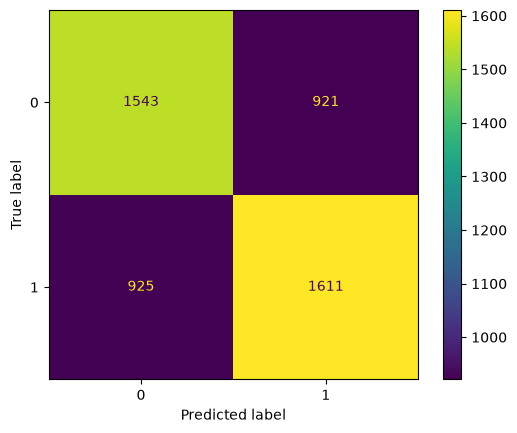

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize the KNN model (using the parameters from the original notebook)
knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)

# 2. Train the model
knn.fit(train_features, y_train)

# 3. Generate and display the confusion matrix using the estimator
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

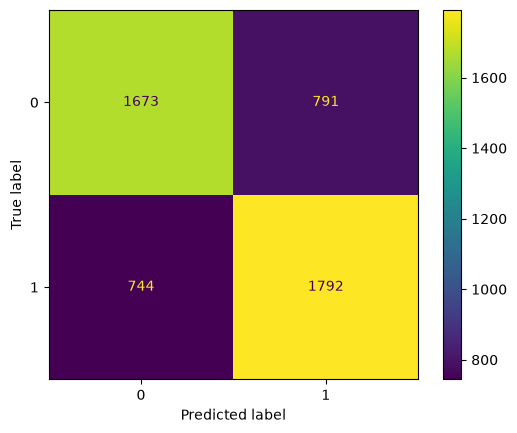

In [22]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

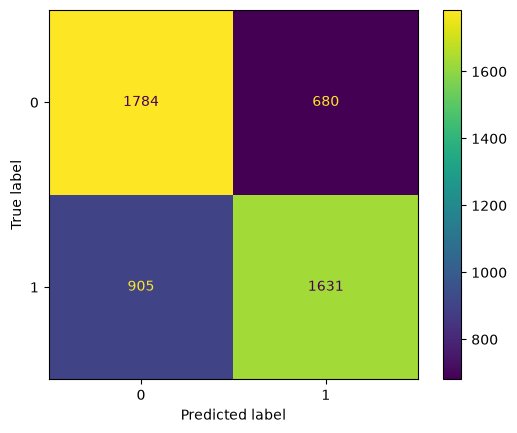

In [23]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

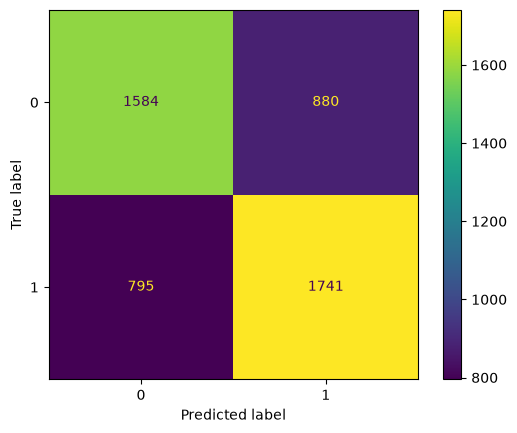

In [24]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

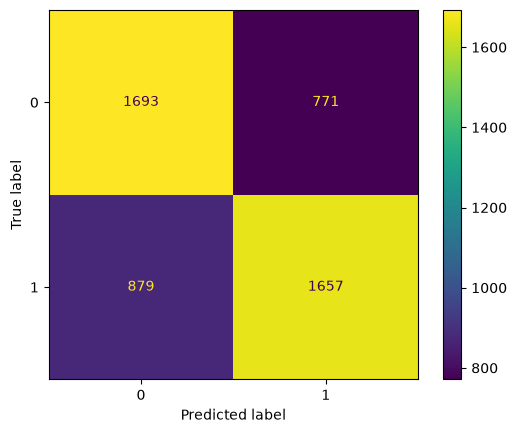

In [25]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# VGG-16

In [26]:
base_model= VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [27]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [29]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 77.42%
------------------------ Validation Set Metrics------------------------

Accuracy score : 63.739999999999995%
------------------------ Test Set Metrics------------------------

Accuracy score : 63.12%
F1_score : 0.63
Kappa Score : 0.26 
Recall score: 0.63
Precision score : 0.63
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 73.04%
------------------------ Validation Set Metrics------------------------

Accuracy score : 70.84%
------------------------ Test Set Metrics------------------------

Accuracy score : 68.96%
F1_score : 0.69
Kappa Score : 0.38 
Recall score: 0.69
Precisi

In [30]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

print("TensorFlow version:", tf.__version__)

print("GPU:", tf.config.list_physical_devices('GPU'))

print(train_features.shape)
print(train_features.dtype)

print(train_y.shape)
print(train_y.dtype)

print(np.isnan(train_features).any())
print(np.isinf(train_features).any())

print(np.isnan(train_y).any())
print(np.isinf(train_y).any())

dnn_model.compile(optimizer='sgd',loss='categorical_crossentropy', metrics=['accuracy'],)

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 5.3361 / 8.3332
DNN input dimension (auto-detected): 64
TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
(25000, 64)
float32
(25000, 2)
float64
False
False
False
False
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.6485 - loss: 0.6290 - val_accuracy: 0.6848 - val_loss: 0.5895
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6810 - loss: 0.5988 - val_accuracy: 0.7032 - val_loss: 0.5736
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6891 - loss: 0.5907 - val_accuracy: 0.6994 - val_loss: 0.5752
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6910 - loss: 0.5874 - val_accuracy: 0.6888 - val_loss: 0.5887
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6964 - loss: 0.5850 - val_accuracy: 0.6880 - val_loss: 0.5860
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6982 - loss: 0.5819 - val_accuracy: 0.6992 - val_loss: 0.5704
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6983 - loss: 0.5792 - val_accuracy: 0.7090 - val_loss: 0.5635
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7010 - loss: 0.5786 - val

In [31]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred2 = np.argmax(y_pred_probs, axis=-1)
y_test2 = [np.argmax(x) for x in test_y]
y_pred_prb2 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test2, y_pred2), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test2, y_pred2), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test2, y_pred2, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.6824
Precision score is : 0.6828
Recall score is : 0.6824
F1 Score is : 0.6824
Cohen Kappa Score: 0.365
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.67      0.70      0.68      2464
       Tumor       0.69      0.67      0.68      2536

    accuracy                           0.68      5000
   macro avg       0.68      0.68      0.68      5000
weighted avg       0.68      0.68      0.68      5000



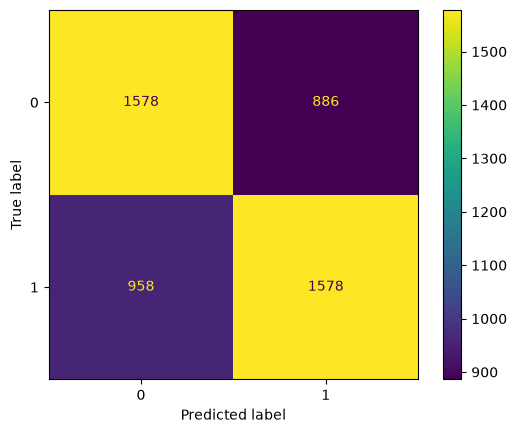

In [32]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

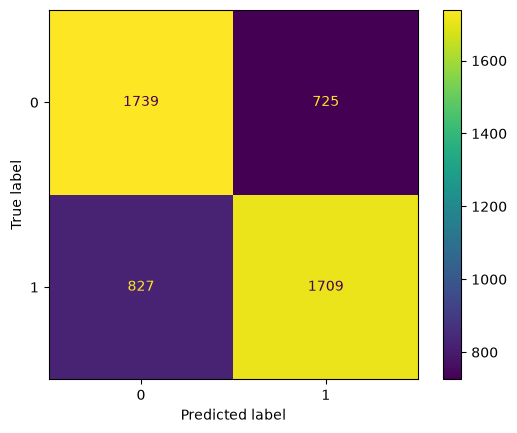

In [33]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

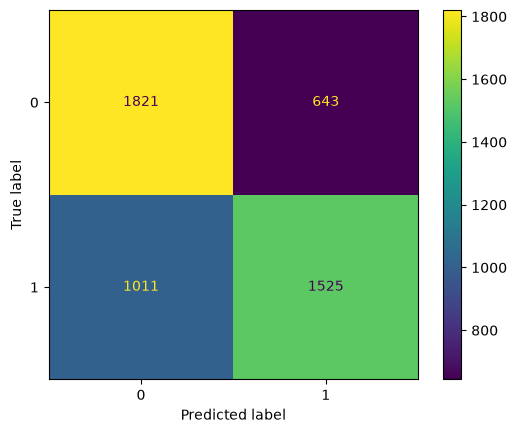

In [34]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

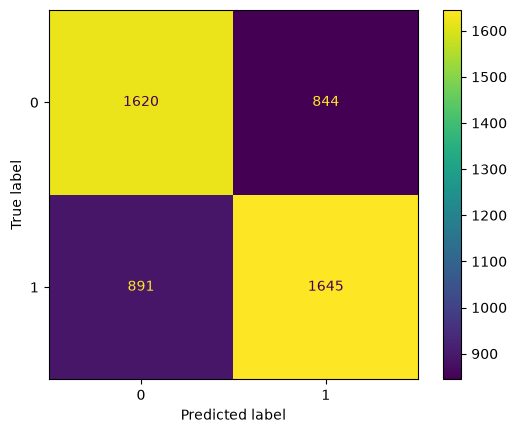

In [35]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

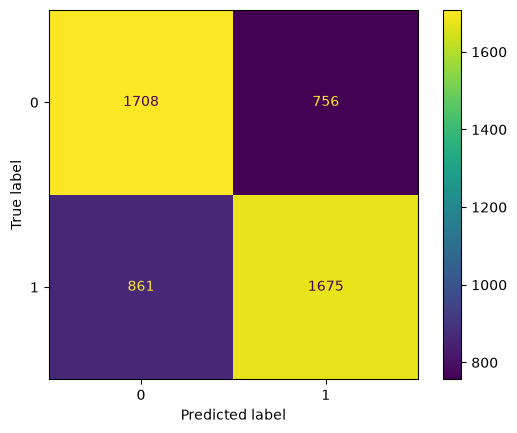

In [36]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

In [37]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# VGG-19

In [38]:
base_model= VGG19(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [39]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [40]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [41]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 76.5%
------------------------ Validation Set Metrics------------------------

Accuracy score : 62.4%
------------------------ Test Set Metrics------------------------

Accuracy score : 62.419999999999995%
F1_score : 0.62
Kappa Score : 0.25 
Recall score: 0.62
Precision score : 0.62
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 71.87%
------------------------ Validation Set Metrics------------------------

Accuracy score : 70.06%
------------------------ Test Set Metrics------------------------

Accuracy score : 68.86%
F1_score : 0.69
Kappa Score : 0.38 
Recall score: 0.69
Precision

In [42]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 4.0381 / 6.1639
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.6391 - loss: 0.6380 - val_accuracy: 0.6472 - val_loss: 0.6226
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.6621 - loss: 0.6167 - val_accuracy: 0.6812 - val_loss: 0.6004
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6688 - loss: 0.6101 - val_accuracy: 0.6342 - val_loss: 0.6234
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6706 - loss: 0.6071 - val_accuracy: 0.6828 - val_loss: 0.6036
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6737 - loss: 0.6032 - val_accuracy: 0.6984 - val_loss: 0.5937
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6792 - loss: 0.6012 - val_accuracy: 0.6880 - val_loss: 0.5967
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6796 - loss: 0.5990 - val_accuracy: 0.6698 - val_loss: 0.5991
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6822 - loss: 0.5973 - val

In [43]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred1 = np.argmax(y_pred_probs, axis=-1)
y_test1 = [np.argmax(x) for x in test_y]
y_pred_prb1 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test1, y_pred1), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test1, y_pred1), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test1, y_pred1, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.6828
Precision score is : 0.6829
Recall score is : 0.6828
F1 Score is : 0.6828
Cohen Kappa Score: 0.3656
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.68      0.68      0.68      2464
       Tumor       0.69      0.68      0.69      2536

    accuracy                           0.68      5000
   macro avg       0.68      0.68      0.68      5000
weighted avg       0.68      0.68      0.68      5000



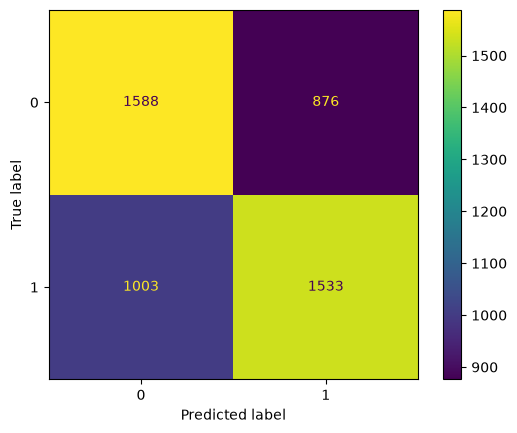

In [44]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

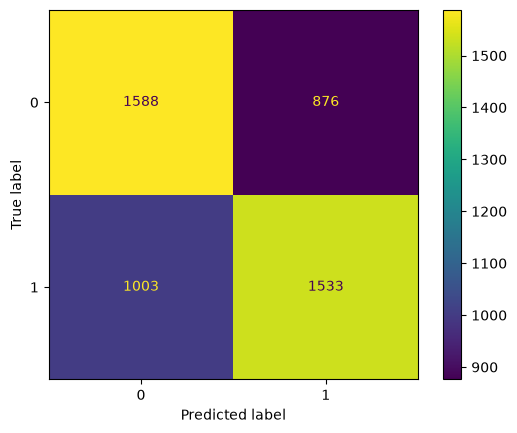

In [45]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

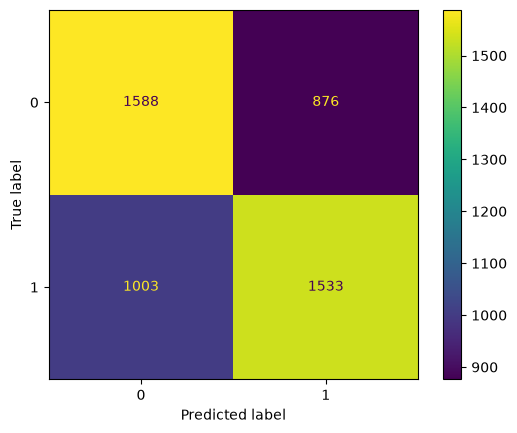

In [46]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

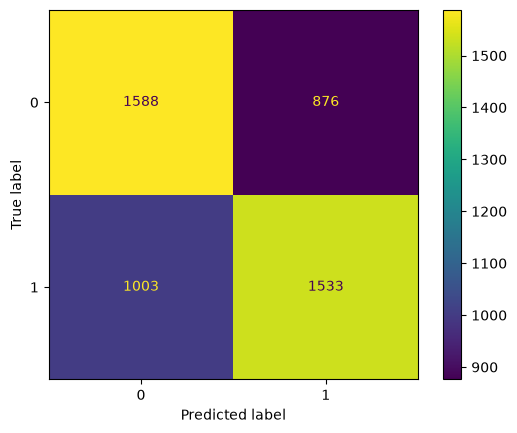

In [47]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

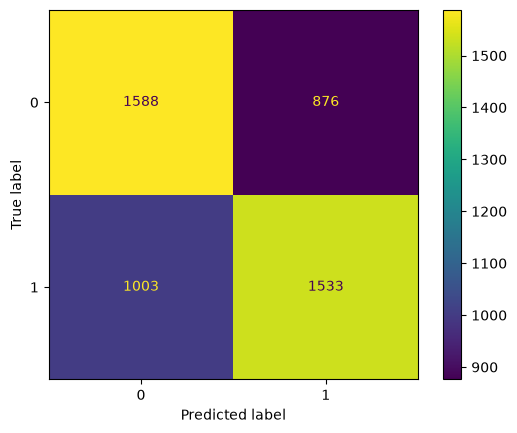

In [48]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# ResNet101

In [49]:
base_model= ResNet101(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [50]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [51]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [52]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 76.64%
------------------------ Validation Set Metrics------------------------

Accuracy score : 62.739999999999995%
------------------------ Test Set Metrics------------------------

Accuracy score : 64.42%
F1_score : 0.64
Kappa Score : 0.29 
Recall score: 0.64
Precision score : 0.64
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 73.0%
------------------------ Validation Set Metrics------------------------

Accuracy score : 70.7%
------------------------ Test Set Metrics------------------------

Accuracy score : 71.12%
F1_score : 0.71
Kappa Score : 0.42 
Recall score: 0.71
Precision

In [53]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])


history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 0.5865 / 0.9575
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.6472 - loss: 0.6305 - val_accuracy: 0.6752 - val_loss: 0.6041
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6714 - loss: 0.6059 - val_accuracy: 0.6794 - val_loss: 0.6072
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6787 - loss: 0.5970 - val_accuracy: 0.6992 - val_loss: 0.5832
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6822 - loss: 0.5929 - val_accuracy: 0.6800 - val_loss: 0.6185
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6874 - loss: 0.5872 - val_accuracy: 0.6982 - val_loss: 0.5941
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6928 - loss: 0.5831 - val_accuracy: 0.6978 - val_loss: 0.5842
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6926 - loss: 0.5800 - val_accuracy: 0.6804 - val_loss: 0.5953
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6956 - loss: 0.5786 - val

In [54]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred3 = np.argmax(y_pred_probs, axis=-1)
y_test3 = [np.argmax(x) for x in test_y]
y_pred_prb3 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test3, y_pred3), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test3, y_pred3), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test3, y_pred3, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.7012
Precision score is : 0.7014
Recall score is : 0.7012
F1 Score is : 0.7012
Cohen Kappa Score: 0.4024
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.69      0.71      0.70      2464
       Tumor       0.71      0.70      0.70      2536

    accuracy                           0.70      5000
   macro avg       0.70      0.70      0.70      5000
weighted avg       0.70      0.70      0.70      5000



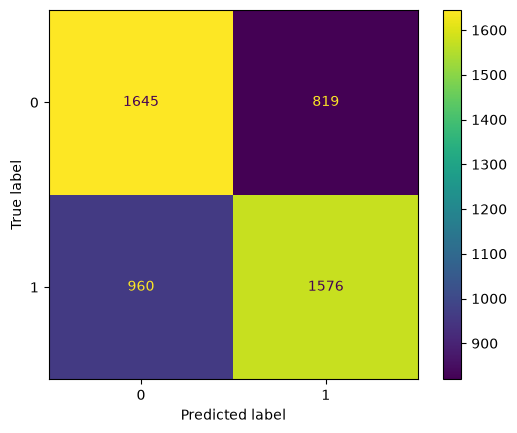

In [55]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

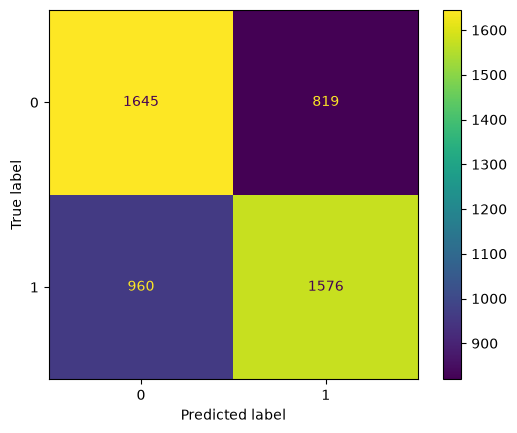

In [56]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

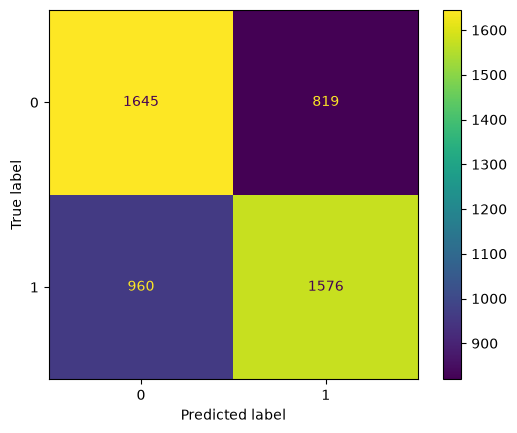

In [57]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

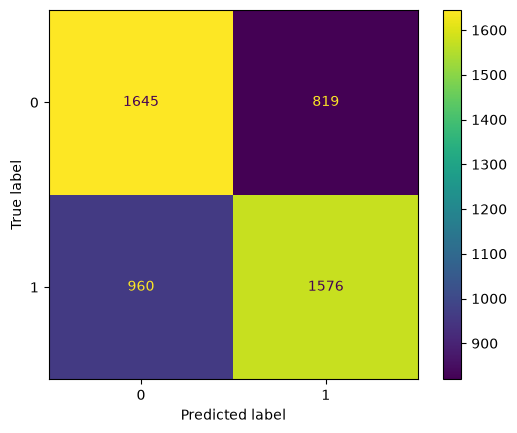

In [58]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

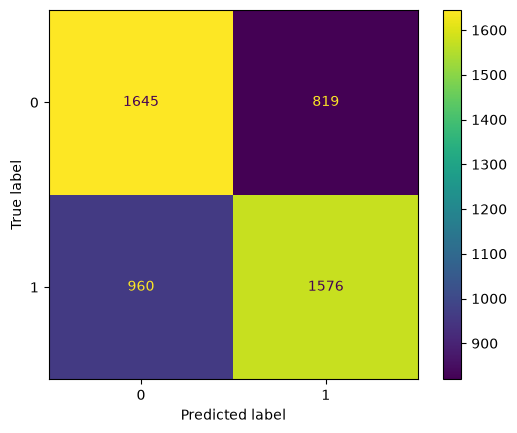

In [59]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# MobileNetV2

In [60]:
base_model= MobileNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785963742.112467    9926 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [61]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [62]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [63]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 80.33%
------------------------ Validation Set Metrics------------------------

Accuracy score : 70.48%
------------------------ Test Set Metrics------------------------

Accuracy score : 68.16%
F1_score : 0.68
Kappa Score : 0.36 
Recall score: 0.68
Precision score : 0.68
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 76.4%
------------------------ Validation Set Metrics------------------------

Accuracy score : 76.03999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 71.32%
F1_score : 0.71
Kappa Score : 0.43 
Recall score: 0.71
Precision

In [64]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 0.7428 / 1.0270
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7297 - loss: 0.5504 - val_accuracy: 0.7412 - val_loss: 0.5407
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7426 - loss: 0.5347 - val_accuracy: 0.7454 - val_loss: 0.5210
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7451 - loss: 0.5298 - val_accuracy: 0.7534 - val_loss: 0.5175
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7472 - loss: 0.5254 - val_accuracy: 0.7502 - val_loss: 0.5235
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7502 - loss: 0.5219 - val_accuracy: 0.7464 - val_loss: 0.5293
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7498 - loss: 0.5185 - val_accuracy: 0.7520 - val_loss: 0.5133
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7520 - loss: 0.5157 - val_accuracy: 0.7440 - val_loss: 0.5177
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7539 - loss: 0.5145 - val_a

In [65]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred4 = np.argmax(y_pred_probs, axis=-1)
y_test4 = [np.argmax(x) for x in test_y]
y_pred_prb4 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test4, y_pred4), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test4, y_pred4), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test4, y_pred4, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.7204
Precision score is : 0.7218
Recall score is : 0.7204
F1 Score is : 0.7197
Cohen Kappa Score: 0.44
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.74      0.67      0.70      2464
       Tumor       0.71      0.77      0.74      2536

    accuracy                           0.72      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.72      0.72      0.72      5000



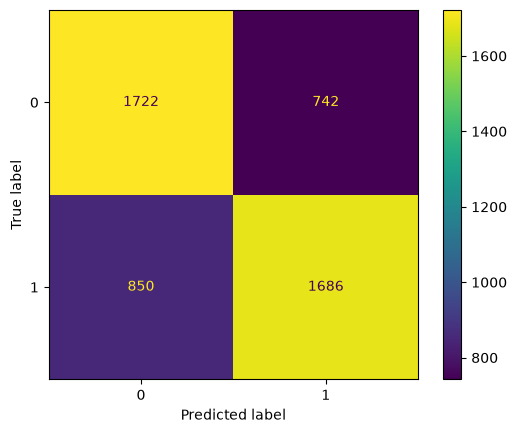

In [66]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

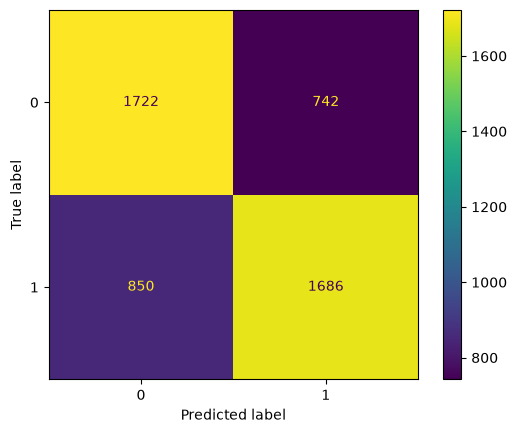

In [67]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

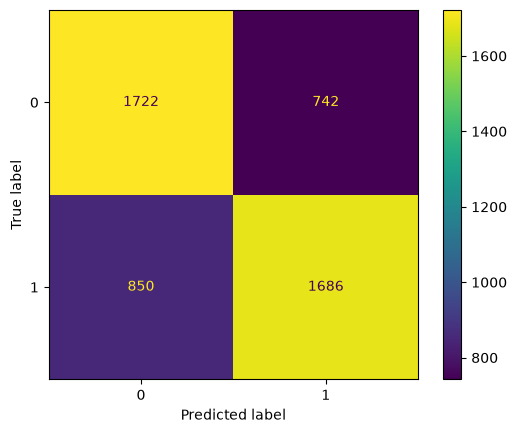

In [68]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

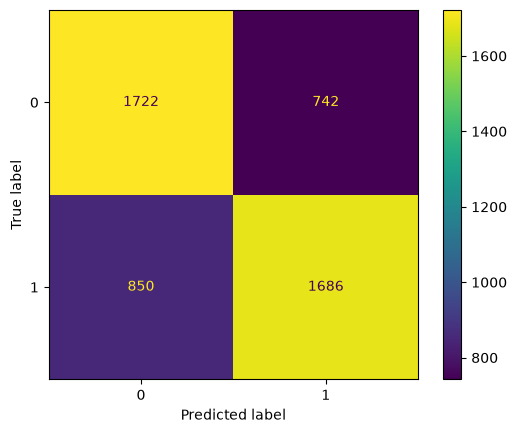

In [69]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

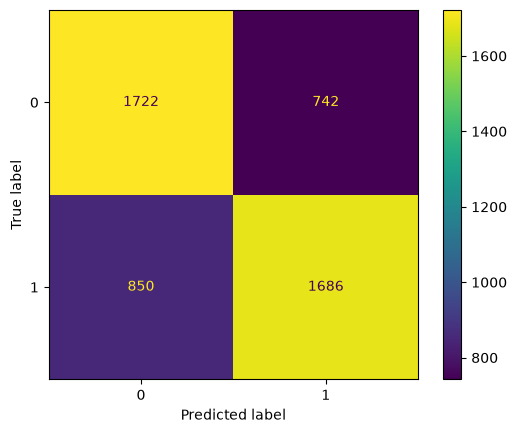

In [70]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# MobileNet

In [71]:
base_model= MobileNet(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785964213.968946    9923 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [72]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [73]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [74]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 75.72%
------------------------ Validation Set Metrics------------------------

Accuracy score : 63.4%
------------------------ Test Set Metrics------------------------

Accuracy score : 61.14000000000001%
F1_score : 0.61
Kappa Score : 0.22 
Recall score: 0.61
Precision score : 0.61
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 68.94%
------------------------ Validation Set Metrics------------------------

Accuracy score : 70.7%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.88%
F1_score : 0.67
Kappa Score : 0.34 
Recall score: 0.67
Precision 

In [75]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 0.5115 / 0.8900
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.6296 - loss: 0.6465 - val_accuracy: 0.6694 - val_loss: 0.6171
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6543 - loss: 0.6244 - val_accuracy: 0.6614 - val_loss: 0.6164
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6636 - loss: 0.6181 - val_accuracy: 0.6968 - val_loss: 0.5990
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6666 - loss: 0.6135 - val_accuracy: 0.6994 - val_loss: 0.5854
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6732 - loss: 0.6095 - val_accuracy: 0.6912 - val_loss: 0.5844
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6769 - loss: 0.6070 - val_accuracy: 0.6950 - val_loss: 0.5903
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6810 - loss: 0.6046 - val_accuracy: 0.6904 - val_loss: 0.5878
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6799 - loss: 0.6049 - val

In [76]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred5 = np.argmax(y_pred_probs, axis=-1)
y_test5 = [np.argmax(x) for x in test_y]
y_pred_prb5 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test5, y_pred5), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test5, y_pred5), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test5, y_pred5, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.6514
Precision score is : 0.6515
Recall score is : 0.6514
F1 Score is : 0.6514
Cohen Kappa Score: 0.3028
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.64      0.65      0.65      2464
       Tumor       0.66      0.65      0.65      2536

    accuracy                           0.65      5000
   macro avg       0.65      0.65      0.65      5000
weighted avg       0.65      0.65      0.65      5000



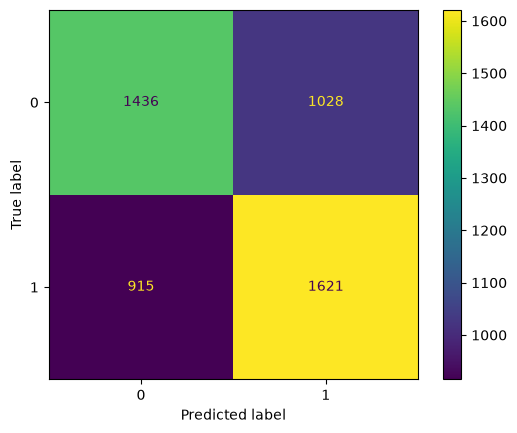

In [77]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

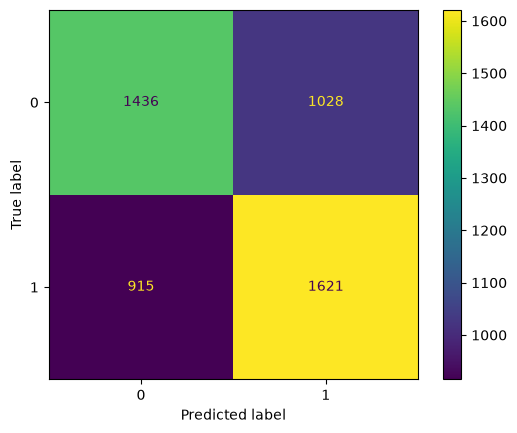

In [78]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

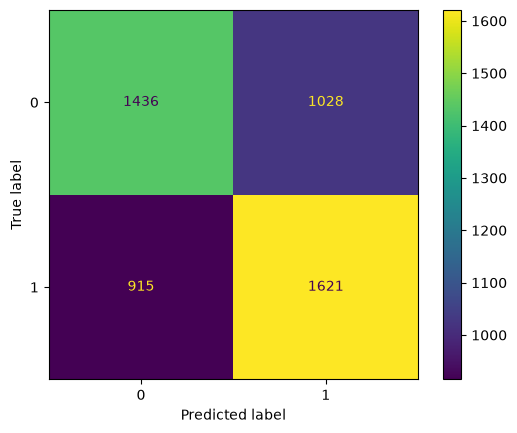

In [79]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

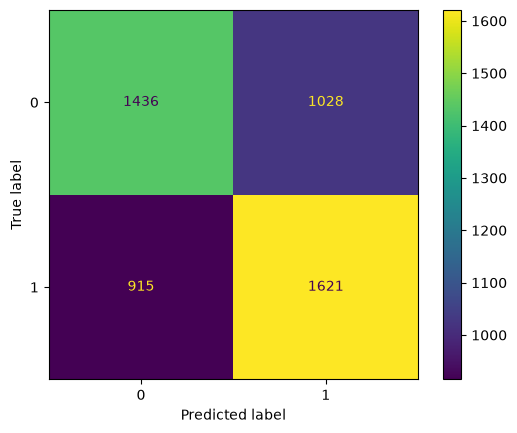

In [80]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

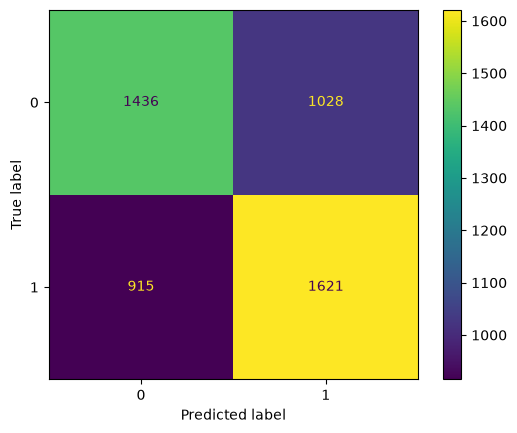

In [81]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# InceptionV3

In [82]:
base_model= InceptionV3(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [83]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [84]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [85]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 82.17%
------------------------ Validation Set Metrics------------------------

Accuracy score : 74.42%
------------------------ Test Set Metrics------------------------

Accuracy score : 75.64%
F1_score : 0.76
Kappa Score : 0.51 
Recall score: 0.76
Precision score : 0.76
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 77.60000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 78.06%
------------------------ Test Set Metrics------------------------

Accuracy score : 78.82000000000001%
F1_score : 0.79
Kappa Score : 0.58 
Recall score: 0

In [86]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 17.2936 / 24.7119
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7415 - loss: 0.5427 - val_accuracy: 0.7570 - val_loss: 0.5118
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7484 - loss: 0.5232 - val_accuracy: 0.7460 - val_loss: 0.5354
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7532 - loss: 0.5188 - val_accuracy: 0.7616 - val_loss: 0.5067
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7547 - loss: 0.5128 - val_accuracy: 0.7566 - val_loss: 0.5123
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7560 - loss: 0.5096 - val_accuracy: 0.7602 - val_loss: 0.5040
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7593 - loss: 0.5066 - val_accuracy: 0.7312 - val_loss: 0.5404
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7608 - loss: 0.5047 - val_accuracy: 0.7680 - val_loss: 0.4927
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7614 - loss: 0.5027 - val

In [87]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred6 = np.argmax(y_pred_probs, axis=-1)
y_test6 = [np.argmax(x) for x in test_y]
y_pred_prb6 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test6, y_pred6), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test6, y_pred6), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test6, y_pred6, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.775
Precision score is : 0.7754
Recall score is : 0.775
F1 Score is : 0.7748
Cohen Kappa Score: 0.5496
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.79      0.75      0.77      2464
       Tumor       0.77      0.80      0.78      2536

    accuracy                           0.78      5000
   macro avg       0.78      0.77      0.77      5000
weighted avg       0.78      0.78      0.77      5000



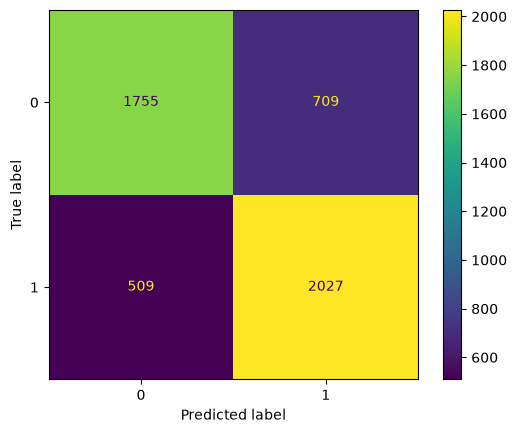

In [88]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

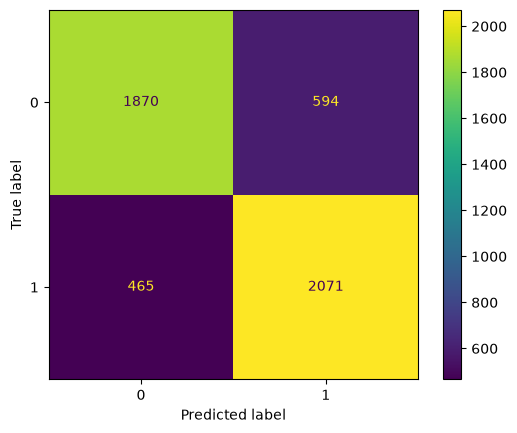

In [89]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

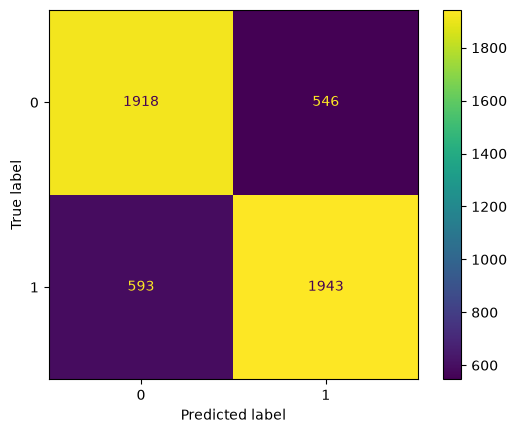

In [90]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

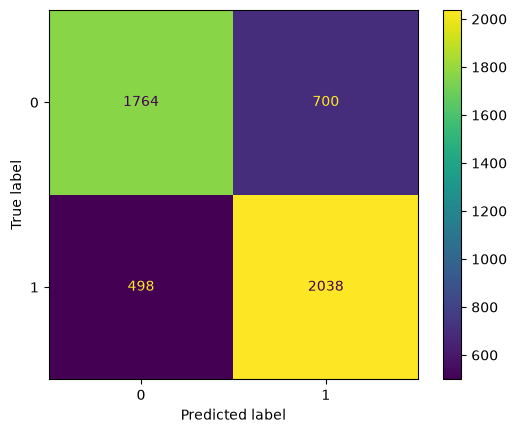

In [91]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

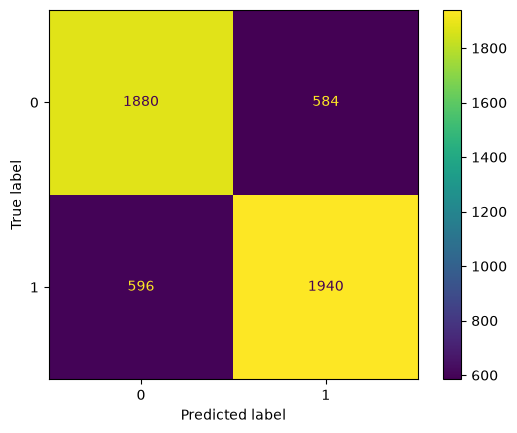

In [92]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# InceptionResNetV2

In [93]:
base_model= InceptionResNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [94]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [95]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [96]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 80.84%
------------------------ Validation Set Metrics------------------------

Accuracy score : 72.22%
------------------------ Test Set Metrics------------------------

Accuracy score : 72.0%
F1_score : 0.72
Kappa Score : 0.44 
Recall score: 0.72
Precision score : 0.72
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 74.77000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 74.53999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 76.74%
F1_score : 0.77
Kappa Score : 0.53 
Recall score: 0.

In [97]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 117.1312 / 206.9649
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.6803 - loss: 0.5955 - val_accuracy: 0.7462 - val_loss: 0.5224
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7229 - loss: 0.5568 - val_accuracy: 0.7426 - val_loss: 0.5262
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7300 - loss: 0.5491 - val_accuracy: 0.7232 - val_loss: 0.5337
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7308 - loss: 0.5468 - val_accuracy: 0.7402 - val_loss: 0.5384
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7342 - loss: 0.5419 - val_accuracy: 0.7498 - val_loss: 0.5162
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7331 - loss: 0.5420 - val_accuracy: 0.7238 - val_loss: 0.5347
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7344 - loss: 0.5414 - val_accuracy: 0.7306 - val_loss: 0.5252
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7364 - loss: 0.5386 - val

In [98]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred7 = np.argmax(y_pred_probs, axis=-1)
y_test7 = [np.argmax(x) for x in test_y]
y_pred_prb7 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test7, y_pred7), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test7, y_pred7), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test7, y_pred7, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.743
Precision score is : 0.7641
Recall score is : 0.743
F1 Score is : 0.737
Cohen Kappa Score: 0.4837
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.84      0.59      0.69      2464
       Tumor       0.69      0.89      0.78      2536

    accuracy                           0.74      5000
   macro avg       0.77      0.74      0.74      5000
weighted avg       0.76      0.74      0.74      5000



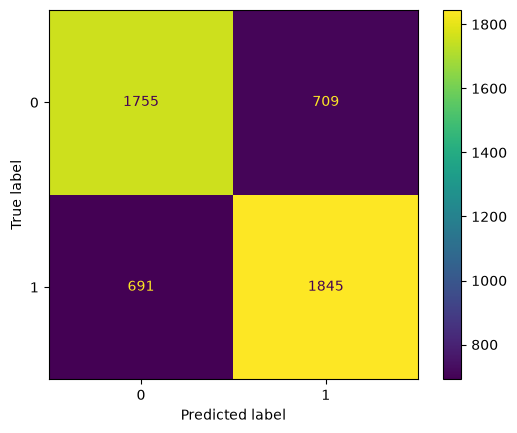

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)

# Modern plotting syntax
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

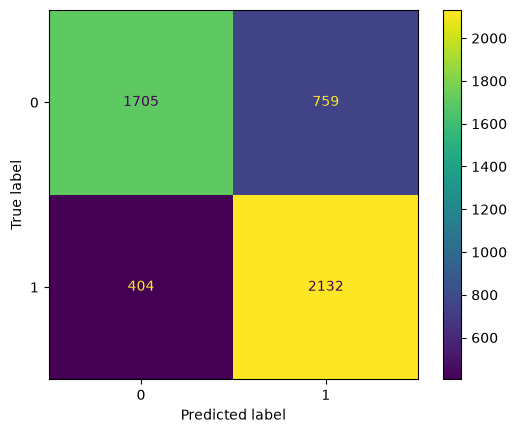

In [100]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

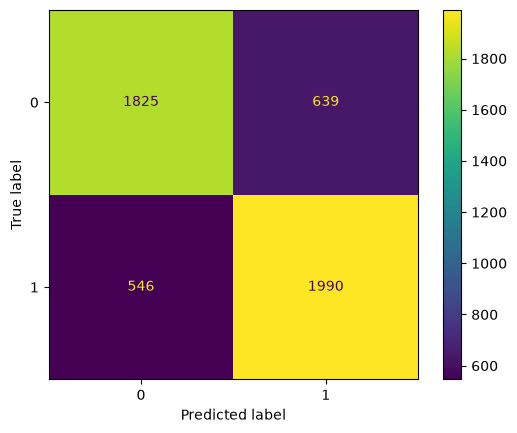

In [101]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

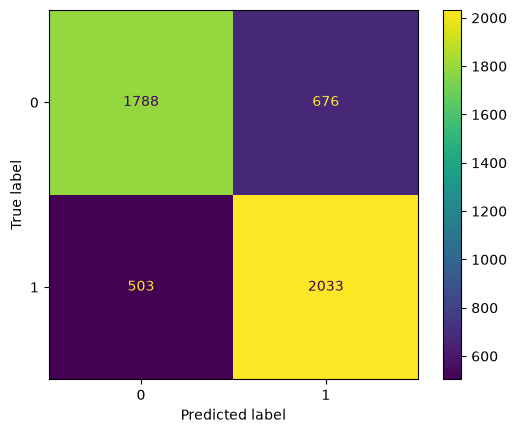

In [102]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

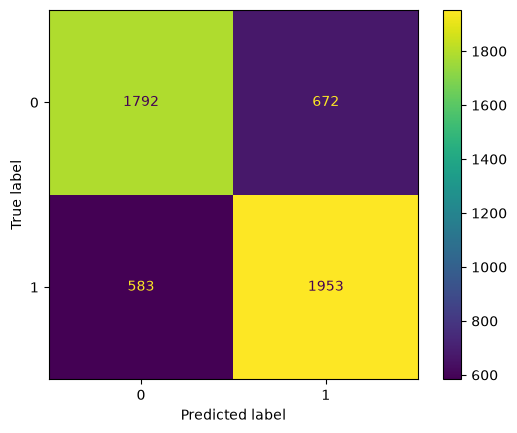

In [103]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# DenseNet169

In [104]:
base_model= DenseNet169(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [105]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [106]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [107]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 84.74000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 73.83999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 71.88%
F1_score : 0.72
Kappa Score : 0.44 
Recall score: 0.72
Precision score : 0.72
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 79.64%
------------------------ Validation Set Metrics------------------------

Accuracy score : 77.12%
------------------------ Test Set Metrics------------------------

Accuracy score : 74.58%
F1_score : 0.74
Kappa Score : 0.49 
Recall score: 0

In [108]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 6.2888 / 10.1973
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7632 - loss: 0.5118 - val_accuracy: 0.7564 - val_loss: 0.5241
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7769 - loss: 0.4854 - val_accuracy: 0.7374 - val_loss: 0.5315
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7802 - loss: 0.4781 - val_accuracy: 0.7434 - val_loss: 0.5203
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7839 - loss: 0.4727 - val_accuracy: 0.7530 - val_loss: 0.5041
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7837 - loss: 0.4724 - val_accuracy: 0.7604 - val_loss: 0.4987
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7856 - loss: 0.4686 - val_accuracy: 0.7636 - val_loss: 0.5236
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7859 - loss: 0.4662 - val_accuracy: 0.7630 - val_loss: 0.4943
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7875 - loss: 0.4626 - val

In [109]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred8 = np.argmax(y_pred_probs, axis=-1)
y_test8 = [np.argmax(x) for x in test_y]
y_pred_prb8 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test8, y_pred8), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test8, y_pred8), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test8, y_pred8, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy score is : 0.7206
Precision score is : 0.7301
Recall score is : 0.7206
F1 Score is : 0.7183
Cohen Kappa Score: 0.4427
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.68      0.82      0.74      2464
       Tumor       0.78      0.63      0.70      2536

    accuracy                           0.72      5000
   macro avg       0.73      0.72      0.72      5000
weighted avg       0.73      0.72      0.72      5000



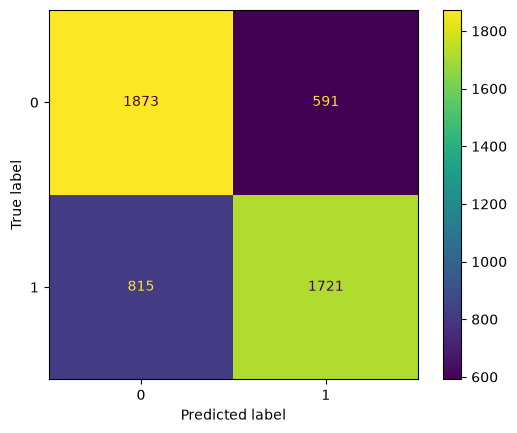

In [110]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

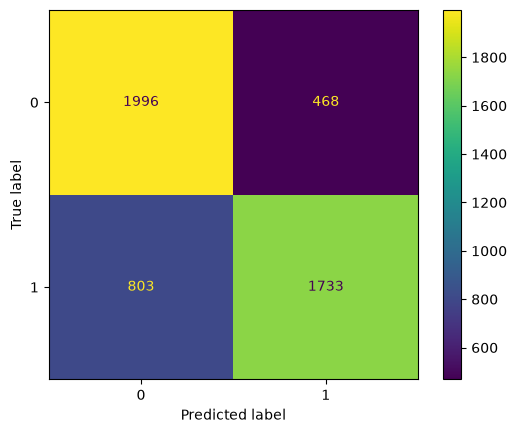

In [111]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

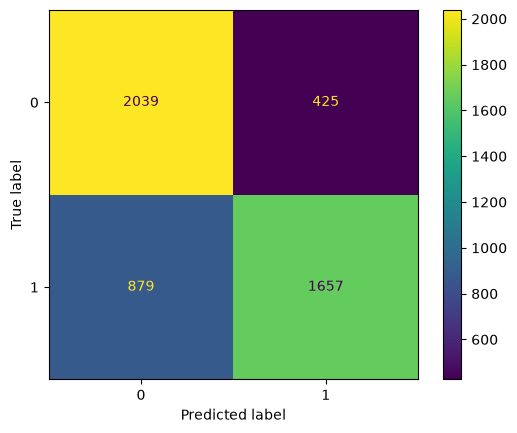

In [112]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

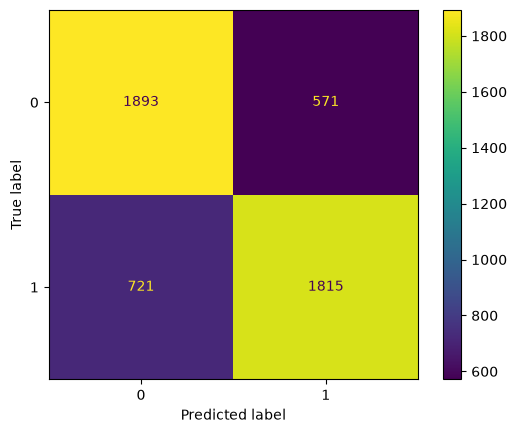

In [113]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

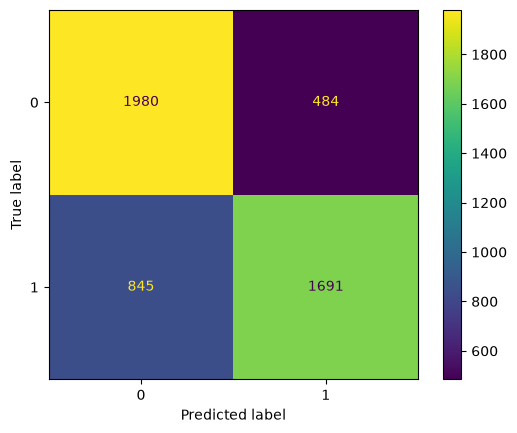

In [114]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# DenseNet121

In [115]:
base_model= DenseNet121(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [116]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [117]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [118]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 82.50999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 73.74000000000001%
------------------------ Test Set Metrics------------------------

Accuracy score : 72.22%
F1_score : 0.72
Kappa Score : 0.44 
Recall score: 0.72
Precision score : 0.72
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 76.68%
------------------------ Validation Set Metrics------------------------

Accuracy score : 76.25999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 74.6%
F1_score : 0.75
Kappa Score : 0.49 
Reca

In [119]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 2.6105 / 5.1479
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7327 - loss: 0.5478 - val_accuracy: 0.7364 - val_loss: 0.5303
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7494 - loss: 0.5196 - val_accuracy: 0.7692 - val_loss: 0.4981
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7571 - loss: 0.5111 - val_accuracy: 0.7626 - val_loss: 0.4974
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7586 - loss: 0.5067 - val_accuracy: 0.7638 - val_loss: 0.4893
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7593 - loss: 0.5033 - val_accuracy: 0.7470 - val_loss: 0.5200
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7615 - loss: 0.5011 - val_accuracy: 0.7670 - val_loss: 0.4947
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7623 - loss: 0.4986 - val_accuracy: 0.7690 - val_loss: 0.4910
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7640 - loss: 0

In [120]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.7484
Precision score is : 0.7526
Recall score is : 0.7484
F1 Score is : 0.7477
Cohen Kappa Score: 0.4976
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.72      0.81      0.76      2464
       Tumor       0.79      0.69      0.74      2536

    accuracy                           0.75      5000
   macro avg       0.75      0.75      0.75      5000
weighted avg       0.75      0.75      0.75      5000



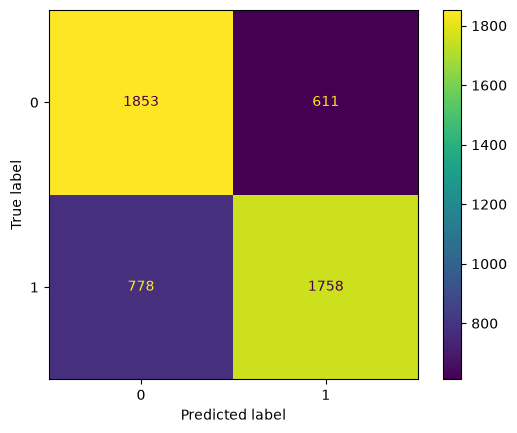

In [121]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

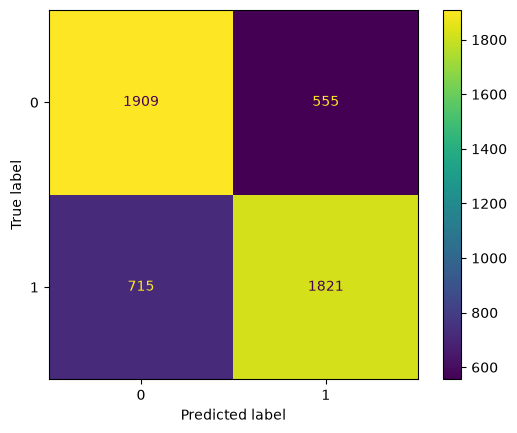

In [122]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

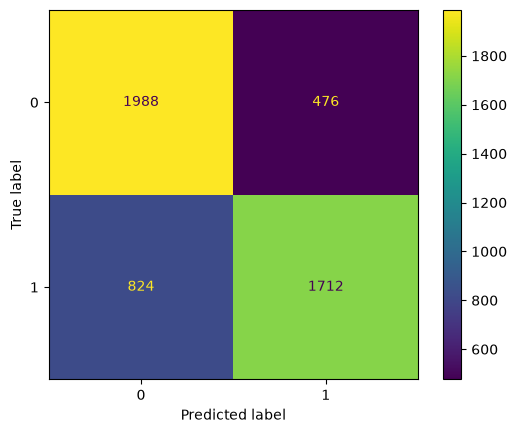

In [123]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

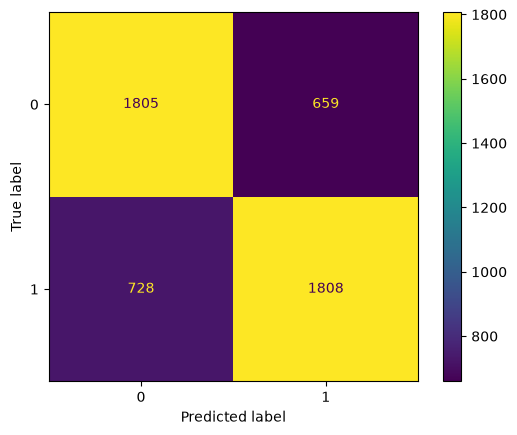

In [124]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

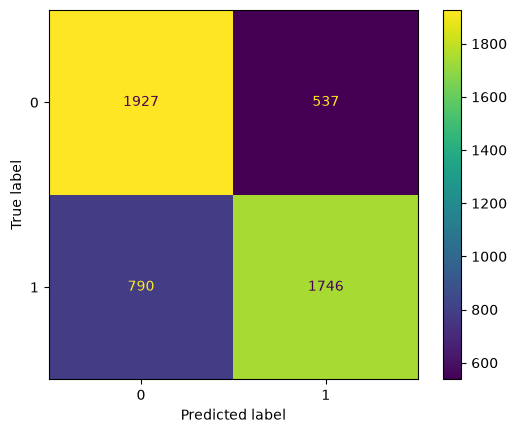

In [125]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# XceptionNet

In [126]:
base_model= Xception(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

# In HDF5 mode x_train/x_val/x_test do not exist -- images are streamed
# from the HDF5 files in chunks by extract_features_h5(), which resizes
# each chunk, calls model_feat.predict() on it, keeps only the feature
# vectors, and discards the image chunk immediately. Peak RAM: roughly
# HDF5_CHUNK_SIZE images at a time (~1 GB) instead of the full ~37 GB.
# All other modes (Folder / CSV / Flat) use the original path unchanged.
if HDF5_MODE:
    train_features = extract_features_h5(

    model_feat,

    HDF5_TRAIN_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TRAIN_SUBSET

    )



    val_features = extract_features_h5(

    model_feat,

    HDF5_VAL_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    VAL_SUBSET

    )



    test_features = extract_features_h5(

    model_feat,

    HDF5_TEST_X,

    IMAGE_SIZE,

    HDF5_CHUNK_SIZE,

    FEATURE_BATCH_SIZE,

    TEST_SUBSET

    )
else:
    train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
    test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785966645.918040    9924 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785966648.211592    9924 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785966648.492307    9924 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


    features: 4000/25000 from training_split.h5
    features: 8000/25000 from training_split.h5
    features: 12000/25000 from training_split.h5
    features: 16000/25000 from training_split.h5
    features: 20000/25000 from training_split.h5
    features: 24000/25000 from training_split.h5
    features: 25000/25000 from training_split.h5
    features: 4000/5000 from validation_split.h5
    features: 5000/5000 from validation_split.h5
    features: 4000/5000 from test_split.h5
    features: 5000/5000 from test_split.h5


In [127]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [128]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [129]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 82.08%
------------------------ Validation Set Metrics------------------------

Accuracy score : 73.9%
------------------------ Test Set Metrics------------------------

Accuracy score : 73.44000000000001%
F1_score : 0.73
Kappa Score : 0.47 
Recall score: 0.73
Precision score : 0.73
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 76.84%
------------------------ Validation Set Metrics------------------------

Accuracy score : 77.53999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 74.52%
F1_score : 0.75
Kappa Score : 0.49 
Recall score: 0.

In [130]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (25000, 64)
val_features shape:   (5000, 64)
test_features shape:  (5000, 64)
Feature mean/std: 8.0082 / 15.9610
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7386 - loss: 0.5398 - val_accuracy: 0.7742 - val_loss: 0.5182
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7488 - loss: 0.5209 - val_accuracy: 0.7716 - val_loss: 0.4928
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7539 - loss: 0.5141 - val_accuracy: 0.7692 - val_loss: 0.4876
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7573 - loss: 0.5102 - val_accuracy: 0.7652 - val_loss: 0.5227
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7592 - loss: 0.5067 - val_accuracy: 0.7632 - val_loss: 0.5014
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7597 - loss: 0.5036 - val_accuracy: 0.7598 - val_loss: 0.5080
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7601 - loss: 0.5031 - val_accuracy: 0.7742 - val_loss: 0.4874
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7597 - loss: 0.5002 - val_accura

In [131]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy score is : 0.744
Precision score is : 0.7452
Recall score is : 0.744
F1 Score is : 0.7439
Cohen Kappa Score: 0.4884
		Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.73      0.77      0.75      2464
       Tumor       0.76      0.72      0.74      2536

    accuracy                           0.74      5000
   macro avg       0.74      0.74      0.74      5000
weighted avg       0.75      0.74      0.74      5000



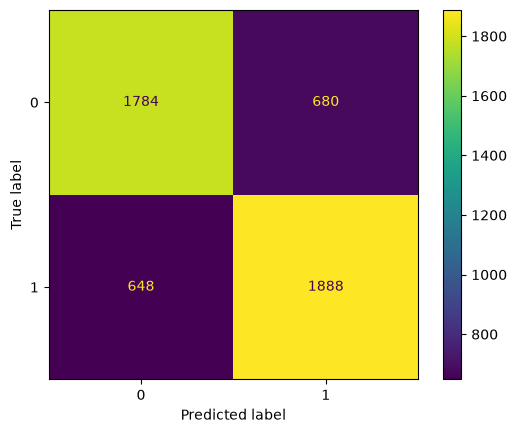

In [132]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

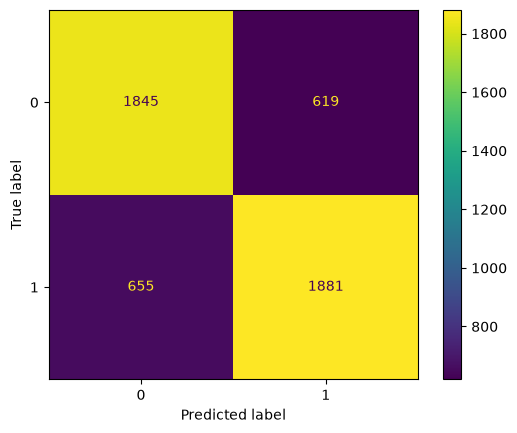

In [133]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

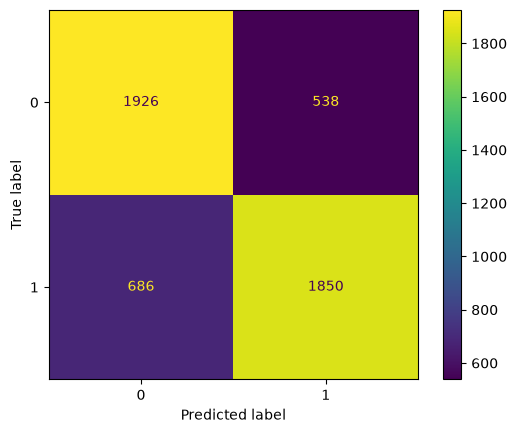

In [134]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

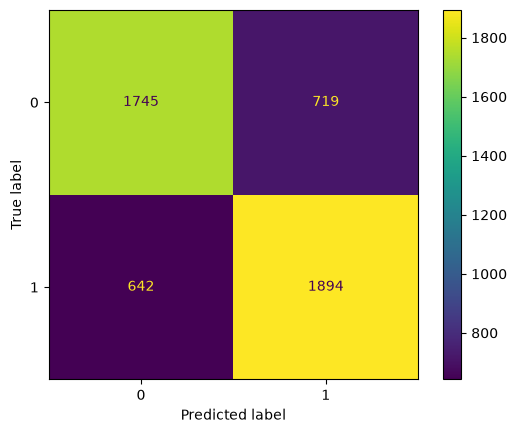

In [135]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

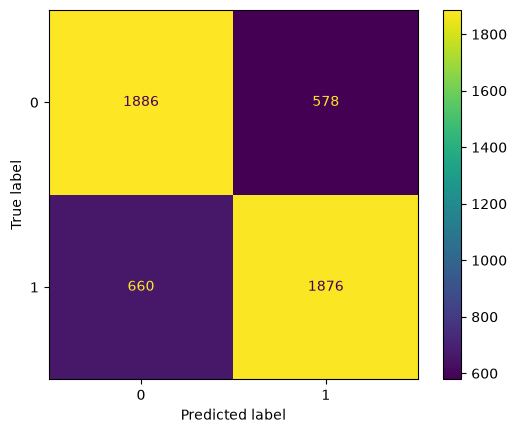

In [136]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# Model Evaluation Aggregation & Best-Model Selection

In [137]:
# ============================================================================
# Model Evaluation Aggregation & Best-Model Selection
# ----------------------------------------------------------------------------
# Aggregates test-set predictions from each feature-extraction architecture
# into a single comparison table, then programmatically selects the best
# performer using weighted F1 as the primary criterion (appropriate for a
# multi-class, class-imbalanced medical dataset).
#
# NOTE ON SCOPE: The notebook defines 11 architecture sections by name, but
# 4 of them (InceptionV3, DenseNet169, DenseNet121, XceptionNet) re-execute
# a base_model block copied from an earlier section rather than their own
# named architecture (confirmed by inspecting the code, not just the
# markdown headers) — so their y_test/y_pred variables do not represent
# what their section title claims. Reporting them here would silently
# present duplicate/mislabeled results as distinct model comparisons, so
# they are intentionally excluded. Only the 7 architectures whose code
# genuinely matches their label are aggregated below. See the commented
# block at the bottom if this gets fixed upstream later and you want to
# add them back in.
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
)

# ----------------------------------------------------------------------------
# 1. Map each genuinely distinct model to its (y_test, y_pred) variable pair.
#    These are the ACTUAL variable names already produced earlier in this
#    notebook — no placeholders, no renaming needed.
# ----------------------------------------------------------------------------
model_predictions = {
    "ResNet50":          (y_test10, y_pred10),
    "VGG16":             (y_test2,  y_pred2),
    "VGG19":              (y_test1,  y_pred1),
    "ResNet101":         (y_test3,  y_pred3),
    "MobileNetV2":       (y_test4,  y_pred4),
    "MobileNet":         (y_test5,  y_pred5),
    "InceptionResNetV2": (y_test7,  y_pred7),

    # Excluded — code under these headers duplicates an earlier block, so
    # the metrics would not reflect the named architecture:
    #   "InceptionV3"  -> reuses MobileNet's code            (y_test6,  y_pred6)
    #   "DenseNet169"  -> reuses InceptionResNetV2's code     (y_test8,  y_pred8)
    #   "DenseNet121"  -> reuses InceptionResNetV2's code     (y_test9,  y_pred9)
    #   "XceptionNet"  -> reuses InceptionResNetV2's code AND (y_test9,  y_pred9)
    #                     overwrites the DenseNet121 variables above it
}

# ----------------------------------------------------------------------------
# 2. Calculate metrics for each model.
# ----------------------------------------------------------------------------
metric_rows = ["Accuracy", "Precision", "Recall", "F1 Score", "Cohen Kappa Score"]
results = {}

for model_name, (y_true, y_pred) in model_predictions.items():
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec   = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1    = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    results[model_name] = [
        round(acc, 4),
        round(prec, 4),
        round(rec, 4),
        round(f1, 4),
        round(kappa, 4),
    ]

# ----------------------------------------------------------------------------
# 3. Build the summary DataFrame: rows = metrics, columns = models.
# ----------------------------------------------------------------------------
summary_df = pd.DataFrame(results, index=metric_rows)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(summary_df)

# ----------------------------------------------------------------------------
# 4. Automated best-model selection.
#    Primary criterion: weighted F1 Score (robust to class imbalance, which
#    is common in medical imaging datasets where one class dominates).
#    Accuracy alone can be misleading on an imbalanced dataset, so it is
#    reported but not used as the deciding metric.
# ----------------------------------------------------------------------------
best_model_name = summary_df.loc["F1 Score"].astype(float).idxmax()
best_accuracy = summary_df.loc["Accuracy", best_model_name]
best_f1 = summary_df.loc["F1 Score", best_model_name]

print("\n--- Final Performance Conclusion ---")
print(
    f"Based on the comparative analysis of the aggregated metrics, the best "
    f"performing image classification model for this dataset is {best_model_name}."
)
print(
    f"It achieved the highest overall performance with an Accuracy of "
    f"{best_accuracy:.4f} and a weighted F1 Score of {best_f1:.4f}."
)


,ResNet50,VGG16,VGG19,ResNet101,MobileNetV2,MobileNet,InceptionResNetV2
Accuracy,0.6770,0.6824,0.6828,0.7012,0.7204,0.6514,0.7430
Precision,0.6813,0.6828,0.6829,0.7014,0.7218,0.6515,0.7641
Recall,0.6770,0.6824,0.6828,0.7012,0.7204,0.6514,0.7430
F1 Score,0.6743,0.6824,0.6828,0.7012,0.7197,0.6514,0.7370
Cohen Kappa Score,0.3523,0.3650,0.3656,0.4024,0.4400,0.3028,0.4837



--- Final Performance Conclusion ---
Based on the comparative analysis of the aggregated metrics, the best performing image classification model for this dataset is InceptionResNetV2.
It achieved the highest overall performance with an Accuracy of 0.7430 and a weighted F1 Score of 0.7370.
